# AI Laptop Advisor — RAG Assistant

A conversational assistant that recommends laptops based on real, retrieved information from Arabic and English sources (articles, price tables, buying guides) — not from the model's general knowledge. It maintains a consistent persona ("Labi"), understands Arabic / English / Franco Arabic, and remembers conversation context across turns.

## Pipeline Overview

1. **Extraction**: PDF files (Arabic + English sources) are converted to text using PyMuPDF, then cleaned (whitespace, noise removal).
2. **Chunking**: cleaned text is split into ~700-character chunks with overlap, low-quality chunks filtered out.
3. **Embedding**: each chunk is vectorized using a multilingual model (`paraphrase-multilingual-mpnet-base-v2`), so Arabic and English content share the same vector space.
4. **Storage**: vectors + text + metadata are stored in a persistent ChromaDB collection.
5. **Query time (RAG)**:
   - Detect the user's language (Arabic / English / Franco Arabic / mixed)
   - Retrieve relevant chunks bilingually (search in the original language + a translated version of the query)
   - Classify the user's intent (vague request, ready to recommend, brand-specific, comparison, general info, price check)
   - Filter/re-rank retrieved chunks based on that intent and file metadata (brand, content type)
   - Generate a response with an LLM (Groq), guided by a persona and strict grounding rules
6. **Grounding check**: before showing the answer, factual claims in it are compared (semantic similarity) against the retrieved context to catch hallucinated numbers or specs.
7. **Memory**: full conversation history is passed to the model each turn, so it can handle follow-ups naturally.

## Notebook Structure

- **Setup & Imports** — installs and imports all required libraries
- **PDF Extraction** — converts raw PDFs into `.txt` files
- **Text Cleaning** — removes extraction noise (extra whitespace, artifacts)
- **Chunking** — splits cleaned text into overlapping chunks, filters out low-quality ones
- **Embedding** — loads the multilingual sentence-transformer model and encodes all chunks
- **Vector Store (ChromaDB)** — persists embeddings + metadata for retrieval
- **LLM Setup** — configures the Groq chat model
- **Language Detection & Bilingual Retrieval** — detects query language and searches in both languages
- **Grounding Check** — semantic similarity check between the answer and retrieved context
- **Intent Classification & Filtered Retrieval** — classifies user intent and re-ranks retrieved chunks accordingly
- **Persona & Main Chain** — defines the assistant's persona, builds the prompt + `ask()` function, and holds conversation memory
- **Manual Test Cases** — example conversations testing language switching, memory, and grounding
- **User File Upload** — lets a user add their own PDF / CSV / Google Sheet to the knowledge base at runtime

### First Section
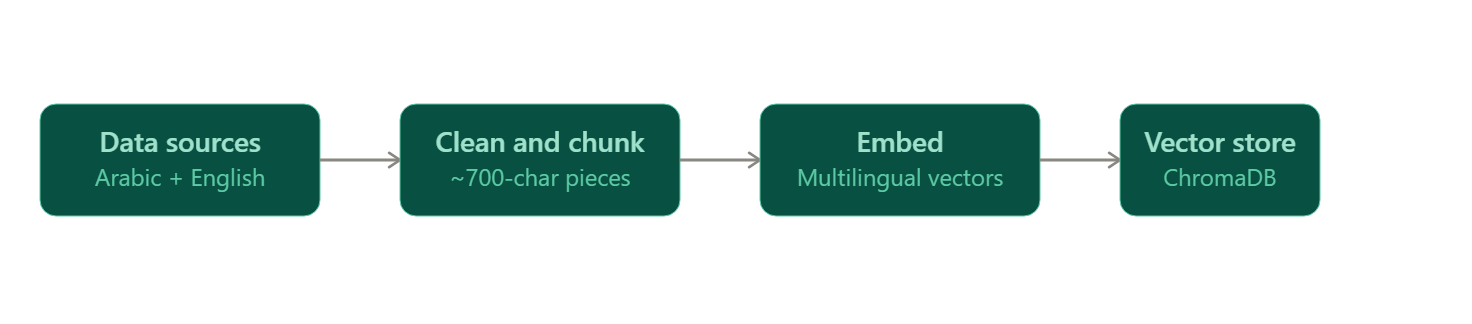

#### 01 Environment Setup and Imports
Setting up the required libraries for the project (PDF extraction, embeddings, vector DB)

In [2]:
%pip install beautifulsoup4 chromadb sentence-transformers langchain pdfplumber PyMuPDF langchain langchain-text-splitters langchain-google-genai langchain-community langchain-chroma sentence-transformers python-dotenv langchain-groq -q pypdf -q pandas openpyxl -q streamlit

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import json
import re
from sentence_transformers import SentenceTransformer
import chromadb
import fitz #PyMuPDF
from langchain_text_splitters import RecursiveCharacterTextSplitter
from dotenv import load_dotenv
from langchain_core.embeddings import Embeddings
from langchain_chroma import Chroma
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_classic.memory import ConversationBufferMemory
from langchain_classic.chains import ConversationalRetrievalChain
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.output_parsers import StrOutputParser
from langchain_groq import ChatGroq
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from pypdf import PdfReader
import pandas as pd

c:\Users\Viola Ibrahim\OneDrive\AI-Laptop-Advisor\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### 02 PDF Extraction
Converting all PDF files in `manuals/raw` into text (.txt) files, saved in `manuals/processed`

In [4]:
raw_dir = os.path.join("..", "manuals", "raw")
processed_dir = os.path.join("..", "manuals", "processed")
os.makedirs(processed_dir, exist_ok=True)

for root, dirs, files in os.walk(raw_dir):
    for filename in files:
        if filename.endswith(".pdf"):
            pdf_path = os.path.join(root, filename)
            txt_filename = os.path.splitext(filename)[0] + ".txt"
            txt_path = os.path.join(processed_dir, txt_filename)  

            doc = fitz.open(pdf_path)
            text = ""
            for page in doc:
                text += page.get_text() + "\n"
            doc.close()

            with open(txt_path, "w", encoding="utf-8") as f:
                f.write(text)

            print(f"✅ {filename} → {txt_filename}")

✅ أهم مواصفات اللاب توب - موضوع.pdf → أهم مواصفات اللاب توب - موضوع.txt
✅ اسعار اللاب توب في مصر 2026_ الجدول الكامل المحدّث شهريًا (بالجنيه) – Dar elcomputer.pdf → اسعار اللاب توب في مصر 2026_ الجدول الكامل المحدّث شهريًا (بالجنيه) – Dar elcomputer.txt
✅ اهم مواصفات اللاب توب _ مواصفات لابتوب للعمل والدراسة.pdf → اهم مواصفات اللاب توب _ مواصفات لابتوب للعمل والدراسة.txt
✅ كيفية اختيار اللابتوب المناسب لاحتياجاتك _ دليل شامل قبل شراء لابتوب جديد - Egygoldentech.pdf → كيفية اختيار اللابتوب المناسب لاحتياجاتك _ دليل شامل قبل شراء لابتوب جديد - Egygoldentech.txt
✅ كيفية اختيار لابتوب مناسب حسب احتياجاتك.. دليل شامل قبل الشراء 2026 - مدونة CIT.pdf → كيفية اختيار لابتوب مناسب حسب احتياجاتك.. دليل شامل قبل الشراء 2026 - مدونة CIT.txt
✅ مواصفات اللابتوب المناسب للألعاب دليل اختيار أفضل جهاز للأداء والسعر.pdf → مواصفات اللابتوب المناسب للألعاب دليل اختيار أفضل جهاز للأداء والسعر.txt
✅ Apple MacBook Lineup Explained_ Which Model Is Right for You - TechWiser.pdf → Apple MacBook Lineup Explained_

In [5]:
metadata_path = os.path.join("..", "manuals", "file_metadata.json")

with open(metadata_path, "r", encoding="utf-8") as f:
    file_metadata = json.load(f)

print(file_metadata["Apple MacBook Lineup Explained_ Which Model Is Right for You - TechWiser.txt"])

{'content_type': 'brand_lineup', 'brand': 'Apple', 'language': 'en'}


#### 03 Text Cleaning
Removing noise from PDF extraction (extra whitespace, page numbers, short junk lines)


In [6]:
def clean_text(text):
    text = re.sub(r' +', ' ', text)
    text = re.sub(r'\n{3,}', '\n\n', text)
    text = re.sub(r'\n\s*(?:Page\s*)?\d+\s*\n', '\n', text)
    text = re.sub(r'^\d+(\.\d+)+\.?\s*', '', text, flags=re.MULTILINE)
    
    navigation_words = [
        'Shop', 'Sidebar', 'Wishlist', 'Cart', 'My account', 'MENU',
        'تابعنا', 'القائمة', 'السلة', 'حسابي', 'البحث',
        'المقالات', 'اكتشاف المزيد', 'المزيد اكتشاف'  
    ]
    lines = text.split('\n')
    lines = [
        line for line in lines 
        if not any(word in line for word in navigation_words) 
        and len(line.strip()) > 3
    ]
    text = '\n'.join(lines)
    text = text.strip()
    return text

In [7]:
for filename in file_metadata.keys():
    txt_path = os.path.join(processed_dir, filename)
    
    with open(txt_path, "r", encoding="utf-8") as f:
        raw_text = f.read()
    
    cleaned = clean_text(raw_text)
    
    with open(txt_path, "w", encoding="utf-8") as f:
        f.write(cleaned)
    
    print(f"cleaned: {filename}")

cleaned: Apple MacBook Lineup Explained_ Which Model Is Right for You - TechWiser.txt
cleaned: Dell Laptop Series Explained (2026)_ New Names Decoded _ Technize.txt
cleaned: Everything to Look for When Buying a New Laptop in 2026 _ WIRED.txt
cleaned: How to Choose the Right Laptop in 2025_2026 - Complete Buying Guide by Landmark Computers.txt
cleaned: HP Laptop Series and Models Explained_ Complete 2026 Guide.txt
cleaned: Laptop Buying Guide 2026_ How to Choose the Right One.txt
cleaned: laptop-buying-guide-checklist.txt
cleaned: Lenovo Laptop Series Explained_ Every Model in 2026 _ Technize.txt
cleaned: Lenovo Vs HP Vs Dell_ Which Laptop Brand Fits You Best_.txt
cleaned: Our definitive laptop purchase advice_ All you need to know to ensure you are getting the perfect laptop for your needs - Notebookcheck Tech.txt
cleaned: What's the Difference Between Lenovo's Many Laptop Models_.txt
cleaned: Which laptop should you prefer Lenovo, Dell, HP, & Mac_.txt
cleaned: اسعار اللاب توب في مصر 2

#### 04 Chunking
Splitting each text into chunks of ~700 characters with 150 character overlap, to preserve context between chunks

In [8]:
processed_dir = os.path.join("..", "manuals", "processed")
metadata_path = os.path.join("..", "manuals", "file_metadata.json")

with open(metadata_path, "r", encoding="utf-8") as f:
    file_metadata = json.load(f)

# LangChain's splitter — respects natural breaks (paragraphs, sentences) before falling back to raw character splitting
splitter = RecursiveCharacterTextSplitter(
    chunk_size=700,
    chunk_overlap=150,
    separators=["\n\n", "\n", ". ", " ", ""]
)

all_chunks = []

for filename, meta in file_metadata.items():
    txt_path = os.path.join(processed_dir, filename)
    
    with open(txt_path, "r", encoding="utf-8") as f:
        text = f.read()
    
    file_chunks = splitter.split_text(text)
    
    for i, chunk in enumerate(file_chunks):
        all_chunks.append({
            "id": f"{filename}_{i}",
            "text": chunk,
            "metadata": {
                **meta,
                "source_file": filename
            }
        })

print(f"Total chunks: {len(all_chunks)}")

Total chunks: 494


In [9]:
def is_low_quality_chunk(text):

    if len(text.strip()) < 100:
        return True
    
    lines = [l for l in text.split('\n') if l.strip()]
    short_lines = [l for l in lines if len(l.strip()) < 15]
    if lines and len(short_lines) / len(lines) > 0.6:
        return True
    return False


all_chunks = [c for c in all_chunks if not is_low_quality_chunk(c["text"])]
print(f"Chunks after filtering: {len(all_chunks)}")

Chunks after filtering: 474


#### 05 Embedding
Converting each chunk into a vector using a multilingual model (`paraphrase-multilingual-mpnet-base-v2`) to support both Arabic and English

In [10]:
model = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10454.76it/s]


In [11]:
texts = [chunk["text"] for chunk in all_chunks]
embeddings = model.encode(texts, show_progress_bar=True)

print(f"Shape: {embeddings.shape}")

Batches: 100%|██████████| 15/15 [03:15<00:00, 13.02s/it]

Shape: (474, 768)


#### 06 Storing in ChromaDB
Storing embeddings, text, and metadata in a local vector database (`data/chroma_db`)

In [12]:
client = chromadb.PersistentClient(path=os.path.join("..", "data", "chroma_db"))
collection = client.create_collection(name="laptop_kb")

ids = [chunk["id"] for chunk in all_chunks]
documents = [chunk["text"] for chunk in all_chunks]
metadatas = [chunk["metadata"] for chunk in all_chunks]

collection.add(
    ids=ids,
    documents=documents,
    metadatas=metadatas,
    embeddings=embeddings.tolist() 
)

print(f"{collection.count()} chunk has been stored at ChromaDB")

474 chunk has been stored at ChromaDB


In [13]:
class SentenceTransformerEmbeddings(Embeddings):
    def __init__(self, model):
        self.model = model
    def embed_documents(self, texts):
        return self.model.encode(texts).tolist()
    def embed_query(self, text):
        return self.model.encode([text])[0].tolist()

lc_embeddings = SentenceTransformerEmbeddings(model)

In [14]:
vectorstore = Chroma(
    client=client,
    collection_name="laptop_kb",
    embedding_function=lc_embeddings
)

retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

In [15]:
# import shutil
# import os

# chroma_path = os.path.join("..", "data", "chroma_db")

# if os.path.exists(chroma_path):
#     shutil.rmtree(chroma_path)
#     print("✅ ChromaDB cleared")

### Second Section
![alt text](image.png)

#### 07 LLM Setup

In [16]:
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.3,
)

#### 08 Intent Classification
Classifying the user's message into one of six intents (vague request, ready to recommend, brand-specific, brand comparison, general info, price check) using a small LLM call. The result later drives retrieval re-ranking and decides whether the grounding check is skipped (e.g. for a clarifying question).

In [17]:
INTENT_PROMPT = """Classify the user's message into ONE intent. Reply with ONLY valid JSON, nothing else.

Intents:
- "vague_request": user wants a laptop recommendation but hasn't given budget AND use case yet
- "ready_to_recommend": user wants a recommendation and has given budget and/or use case
- "brand_specific": user is asking about a specific brand's lineup/models (Dell, HP, Lenovo, Apple)
- "brand_comparison": user wants to compare two or more brands
- "general_info": general question about specs, terminology, or buying advice, not asking for a specific product
- "price_check": asking about price ranges only, not asking for a specific recommendation

Conversation so far:
{history}

User's latest message: {question}

JSON format: {{"intent": "...", "brand": "brand name or null", "needs_clarification": true/false}}"""

def classify_intent(question, chat_history):
    history_text = "\n".join(f"{role}: {msg}" for role, msg in chat_history[-6:])
    raw = llm.invoke(INTENT_PROMPT.format(history=history_text, question=question)).content
    raw = raw.strip().removeprefix("```json").removeprefix("```").removesuffix("```").strip()
    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        return {"intent": "general_info", "brand": None, "needs_clarification": False}

#### 09 Language Detection
Detecting whether the user wrote Arabic, English, mixed, or Franco Arabic (Arabic typed in Latin letters, e.g. `3ayez`), based on the ratio of Arabic to Latin characters plus a regex for common Franco digit substitutions. `LANG_RULES` holds the instruction injected into the prompt for each case, so the assistant always replies in the user's language while keeping English technical terms untouched.

In [18]:
AR = re.compile(r"[\u0600-\u06FF]")
LAT = re.compile(r"[A-Za-z]")
FRANCO = re.compile(r"\b[a-z]{0,4}[23579][a-z]{1,}\b", re.I)

def detect_language(text):
    ar, lat = len(AR.findall(text)), len(LAT.findall(text))
    if ar == 0:
        return "franco" if FRANCO.search(text) else "en"
    if lat == 0:
        return "ar"
    return "ar" if lat / (ar + lat) < 0.4 else "mixed"

LANG_RULES = {
    "ar":     "Respond in Egyptian Arabic. Keep technical terms and model names in English as written (RTX 4060, SSD, Core i7).",
    "en":     "Respond in English, same persona and tone.",
    "mixed":  "Respond in Egyptian Arabic, keeping English technical terms exactly as the user wrote them.",
    "franco": "The user is writing Franco Arabic (Arabic in Latin letters). Respond in normal Egyptian Arabic script — don't mimic their writing style.",
}

# اختبار سريع
for q in ["عايز لابتوب للألعاب", "best laptop for gaming", "3ayez laptop lel games", "عايز لابتوب فيه RTX 4060"]:
    print(detect_language(q), "|", q)

ar | عايز لابتوب للألعاب
en | best laptop for gaming
franco | 3ayez laptop lel games
ar | عايز لابتوب فيه RTX 4060


#### 10 Bilingual Retrieval
Since the knowledge base has both Arabic and English sources, a query in one language can miss relevant chunks written in the other. `translate_query` translates the question to the *other* language, and `bilingual_retrieve` searches with both the original and translated query, then deduplicates the results. `NO_ANSWER_PHRASE` is the fixed sentence the assistant must reply with when the context doesn't contain an answer — checked in a few places downstream.

In [19]:
NO_ANSWER_PHRASE = "I don't have this information right now"

def is_no_answer(answer):
    return NO_ANSWER_PHRASE in answer

def translate_query(q, target):
    result = llm.invoke(
        f"Translate this search query to {target}. Output only the translation:\n{q}"
    ).content
    if isinstance(result, list):
        result = "".join(
            part.get("text", "") if isinstance(part, dict) else str(part)
            for part in result
        )
    return result.strip()

def bilingual_retrieve(question, lang, k=4):
    docs = retriever.invoke(question)
    target = "English" if lang in ("ar", "franco") else "Arabic"
    try:
        docs += retriever.invoke(translate_query(question, target))
    except Exception as e:
        print("translation skipped:", e)

    seen, out = set(), []
    for d in docs:
        key = d.page_content[:120]
        if key not in seen:
            seen.add(key)
            out.append(d)
    return out[:k * 2]

#### 11 Grounding Check
To reduce hallucination, every answer is checked against the retrieved context before being shown. Only sentences containing a factual claim (a number or a known brand/spec term) are checked — conversational filler is skipped. Each factual sentence is embedded and compared (cosine similarity) against the context sentences; if the average similarity falls below the threshold, the answer is replaced with `NO_ANSWER_PHRASE` instead of being shown as-is.

In [20]:
def split_sentences(text):
    sentences = re.split(r'[.!؟?\n]+', text)
    return [s.strip() for s in sentences if len(s.strip()) > 10]

def contains_factual_claim(sentence):
    return bool(re.search(r'\d', sentence)) or any(
        brand in sentence for brand in ["Dell", "HP", "Lenovo", "Apple", "RTX", "Core i", "SSD", "RAM"]
    )

def looks_grounded(answer, context, threshold=0.60):
    if is_no_answer(answer):
        return True, "no_answer", 1.0

    answer_sentences = [s for s in split_sentences(answer) if contains_factual_claim(s)]
    context_sentences = split_sentences(context)

    if not answer_sentences:
        return True, "no_factual_claims", 1.0

    answer_vecs = lc_embeddings.embed_documents(answer_sentences)
    context_vecs = lc_embeddings.embed_documents(context_sentences)
    sims = cosine_similarity(answer_vecs, context_vecs)
    max_sims = sims.max(axis=1)
    avg_similarity = float(np.mean(max_sims))

    if avg_similarity >= threshold:
        return True, "ok", avg_similarity
    return False, f"low similarity ({avg_similarity:.2f})", avg_similarity

#### 12 Intent-Filtered Retrieval
Combines bilingual retrieval with the classified intent: chunks are re-ranked using `file_metadata` so that, for example, a brand-specific question favors chunks whose `brand` field matches, and a comparison question favors chunks tagged `brand_comparison`. This is on top of (not instead of) the bilingual search in step 10.

In [21]:
def filtered_retrieve(question, lang, intent_data, k=4):
    docs = bilingual_retrieve(question, lang, k=k * 2)

    intent = intent_data.get("intent")
    brand = intent_data.get("brand")

    def score(doc):
        meta = file_metadata.get(doc.metadata.get("source_file", ""), {})
        s = 0
        if intent == "brand_specific" and brand and meta.get("brand", "").lower() == brand.lower():
            s += 2
        if intent == "brand_comparison" and meta.get("content_type") == "brand_comparison":
            s += 2
        if intent in ("ready_to_recommend", "price_check") and meta.get("content_type") == "buying_advice":
            s += 1
        return s

    docs.sort(key=score, reverse=True)
    return docs[:k]

#### 13 Persona, Prompt, and Main Chain
Defines the assistant's persona ("Labi"), the conversation-flow rules (ask for budget/use case before recommending, don't repeat questions already answered, answer general questions directly), and the strict accuracy rules (answer only from context, never invent numbers). Builds the LCEL chain (`prompt | llm | StrOutputParser()`) and the `ask()` function that ties everything together: detect language → classify intent → retrieve → generate → grounding check → update `chat_history`.

In [22]:
PERSONA_CORE = """You are "Labi" — an Egyptian laptop advisor with years of experience in the field.

Style:
- Keep it simple and conversational, no unnecessary technical jargon
- If a technical term matters, mention it and explain it briefly
- Be honest: if something isn't worth the money, say so
- Keep answers short and focused, not essays

Conversation flow (important):
- Before recommending any specific laptop, you need to know at minimum: budget, and main use case (gaming, study, design/editing, general use).
- If the user's message doesn't give you enough of this, do NOT recommend anything yet. Instead, ask ONE or TWO short follow-up questions to fill the gap — never a long list of questions at once.
- Check the conversation history: if the user already answered something earlier, don't ask it again. Build on what they've already told you.
- Once you have budget + use case (and any other detail the user volunteers, like screen size or brand preference), give a direct recommendation grounded in the context below — don't keep stalling with more questions once you have enough to answer.
- If the user asks a general/factual question (like "what does GPU mean" or "what's the price range for gaming laptops"), just answer it — you don't need to gather requirements first for informational questions, only before a specific product recommendation.

Accuracy rules (critical, never break these):
- Answer ONLY using the information in the "Available Context" below. Do not use your own general knowledge about laptops or prices.
- If the context does not contain the answer, reply with EXACTLY this phrase: "I don't have this information right now"
- Never invent prices or specs that are not explicitly stated in the context.
- Any number you mention (price, RAM, etc.) must be copied from the context, not estimated or rounded from your own knowledge."""

prompt = ChatPromptTemplate.from_messages([
    ("system", PERSONA_CORE + "\n\n language instructions :\n{lang_rule}\n\n context:\n{context}"),
    MessagesPlaceholder("chat_history"),
    ("human", "{question}"),
])

chain = prompt | llm | StrOutputParser()
chat_history = []

def ask(question, show_sources=True):
    lang = detect_language(question)
    intent_data = classify_intent(question, chat_history)

    docs = filtered_retrieve(question, lang, intent_data)
    context = "\n\n---\n\n".join(d.page_content for d in docs)

    answer = chain.invoke({
        "lang_rule": LANG_RULES[lang],
        "context": context,
        "chat_history": chat_history,
        "question": question,
    }) 
    
    if intent_data.get("needs_clarification"):
        grounded, reason, score = True, "clarifying_question", None
    else:
        grounded, reason, score = looks_grounded(answer, context)
        if not grounded:
            print(f" ungrounded responce: {reason}")
            answer = NO_ANSWER_PHRASE

    chat_history.extend([("human", question), ("ai", answer)])

    print(f"[intent: {intent_data.get('intent')}]")
    print(answer)
    if show_sources and not is_no_answer(answer):
        srcs = {d.metadata.get("source_file", "?") for d in docs}
        score_str = f"{score:.2f}" if score is not None else "n/a"
        print(f"\n[lang: {lang} | grounded: {grounded} | similarity: {score_str} | sources: {len(srcs)}]")
        for s in srcs:
            print("  -", s)
    return answer

#### 14 Manual Test Cases
A short simulated conversation used to manually verify: follow-up question handling without repeating requirements already given, language switching (Arabic, English, Franco Arabic), and grounding on a brand-specific question. These are exploratory checks, not the structured evaluation set for the report.

In [23]:
ask("عايز لابتوب")

[intent: vague_request]
محتاج أعرف شوية تفاصيل عشان أقدر أرشح لك حاجة مناسبة:

1. ميزانيتك تقريبًا إيه؟  
2. هتستخدم اللابتوب لإيه أساسًا؟ (مثلاً ألعاب، دراسة، تصميم/تحرير، أو استخدام عام)

[lang: ar | grounded: True | similarity: n/a | sources: 2]
  - كيفية اختيار لابتوب مناسب حسب احتياجاتك.. دليل شامل قبل الشراء 2026 - مدونة CIT.txt
  - كيفية اختيار اللابتوب المناسب لاحتياجاتك _ دليل شامل قبل شراء لابتوب جديد - Egygoldentech.txt


'محتاج أعرف شوية تفاصيل عشان أقدر أرشح لك حاجة مناسبة:\n\n1. ميزانيتك تقريبًا إيه؟  \n2. هتستخدم اللابتوب لإيه أساسًا؟ (مثلاً ألعاب، دراسة، تصميم/تحرير، أو استخدام عام)'

In [24]:
ask("للألعاب، وميزانيتي حوالي 60 ألف")

[intent: ready_to_recommend]
تمام، مع ميزانية ≈ 60 ألف جنيه ولعب الألعاب، دي أهم الحاجات اللي لازم تدور عليها في اللابتوب:

| المكوّن | ليه مهم | إيه اللي يفضّل تشوفه |
|--------|----------|-------------------|
| **كرت شاشة منفصل** | هو اللي بيحدد أداء الألعاب. | RTX 4050 أو RTX 4060 يكونوا مناسبين للـ 60 ألف جنيه. |
| **الرام** | لتعدد التطبيقات وسلاسة اللعب. | 16 GB RAM يكفي لمعظم الألعاب الحديثة. |
| **التخزين** | سرعة التحميل والـ SSD بيقلل أوقات الانتظار. | SSD سعة 512 GB أو 1 TB لو تقدر. |
| **الشاشة** | جودة الصورة وسرعة الاستجابة. | دقة Full HD مع معدل تحديث ≥ 144 Hz و سطوع كويس. |
| **التبريد** | يمنع ارتفاع الحرارة ويطوّل عمر الجهاز. | نظام تبريد قوي (مراوح متعددة، أنابيب حرارية). |
| **الوزن والحجم** | لو هتسحب اللابتوب معاك. | وزن ≤ 2.5 kg لو هتستخدمه بره البيت كتير. |
| **الضمان والفحص** | عشان تتأكد إن الجهاز سليم ومش نصب. | اختار متجر بيعمل فحص فني كامل وبيوفر ضمان حقيقي، حتى لو السعر أعلى شوية. |

**نصايح عملية:**

1. **ابحث عن موديلات** فيها RTX 4050/4060 + 16 GB RAM +

'تمام، مع ميزانية\u202f≈\u202f60\u202fألف جنيه ولعب الألعاب، دي أهم الحاجات اللي لازم تدور عليها في اللابتوب:\n\n| المكوّن | ليه مهم | إيه اللي يفضّل تشوفه |\n|--------|----------|-------------------|\n| **كرت شاشة منفصل** | هو اللي بيحدد أداء الألعاب. |\u202fRTX\u202f4050\u202fأو\u202fRTX\u202f4060\u202fيكونوا مناسبين للـ\u202f60\u202fألف\u202fجنيه. |\n| **الرام** | لتعدد التطبيقات وسلاسة اللعب. |\u202f16\u202fGB\u202fRAM\u202fيكفي لمعظم الألعاب الحديثة. |\n| **التخزين** | سرعة التحميل والـ\u202fSSD\u202fبيقلل أوقات الانتظار. |\u202fSSD\u202fسعة\u202f512\u202fGB\u202fأو\u202f1\u202fTB\u202fلو تقدر. |\n| **الشاشة** | جودة الصورة وسرعة الاستجابة. |\u202fدقة\u202fFull\u202fHD\u202fمع\u202fمعدل\u202fتحديث\u202f≥\u202f144\u202fHz\u202fو سطوع كويس. |\n| **التبريد** | يمنع ارتفاع الحرارة ويطوّل عمر الجهاز. | نظام تبريد قوي (مراوح متعددة، أنابيب حرارية). |\n| **الوزن والحجم** | لو هتسحب اللابتوب معاك. | وزن\u202f≤\u202f2.5\u202fkg\u202fلو هتستخدمه بره البيت كتير. |\n| **الضمان والفحص** | عشان

In [25]:
ask("طيب وهل يفرق لو اخترت شاشة أعلى؟")

[intent: general_info]
أيوة، اختيار شاشة “أعلى” بيأثر على تجربة اللعب، بس فيه شوية موازين لازم تاخدها في الاعتبار:

| نوع تحسين في الشاشة | الفايدة | العيب / التكلفة |
|-------------------|----------|-----------------|
| **معدل تحديث أعلى (مثلاً 144 Hz أو 165 Hz)** | بيخلي الحركة أ smoother، خصوصًا في ألعاب الـ FPS و الـ Racing؛ بتقلل الـ input lag. | سعر أعلى شوية، وبيستهلك بطارية أكتر. |
| **دقة أعلى (Full HD → QHD → 4K)** | تفاصيل أوضح، مفيدة لو هتعمل مونتاج أو مشاهدة فيديوهات بجودة عالية. | الـ GPU يشتغل أقوى عشان يطلع إطارات كافية، فممكن تحتاج كرت أقوى (مثلاً RTX 4060 بدل RTX 4050) وبالتالي سعر أعلى. |
| **سطوع وتباين أحسن** | شاشة ساطعة ومريحة للعين في الإضاءة القوية، ألوان أحيى. | غالبًا بيكون مع شاشة أغلى أو تقنية OLED/IPS متقدمة. |
| **حجم أكبر** | مساحة مشاهدة أوسع، مريحة للـ multitasking. | وزن أكبر، بطارية أقصر، وسعر أعلى. |

**نصايح عملية:**

1. **لو هدفك أساسي هو الألعاب** – أهم حاجة تكون الشاشة بـ 144 Hz و Full HD. ده بيضمن سلاسة اللعب من غير ما تضغط على الـ GPU كتير.  


'أيوة، اختيار شاشة “أعلى” بيأثر على تجربة اللعب، بس فيه شوية موازين لازم تاخدها في الاعتبار:\n\n| نوع تحسين في الشاشة | الفايدة | العيب / التكلفة |\n|-------------------|----------|-----------------|\n| **معدل تحديث أعلى (مثلاً 144\u202fHz أو 165\u202fHz)** | بيخلي الحركة أ smoother، خصوصًا في ألعاب الـ\u202fFPS و الـ\u202fRacing؛ بتقلل الـ\u202finput lag. | سعر أعلى شوية، وبيستهلك بطارية أكتر. |\n| **دقة أعلى (Full\u202fHD\u202f→\u202fQHD\u202f→\u202f4K)** | تفاصيل أوضح، مفيدة لو هتعمل مونتاج أو مشاهدة فيديوهات بجودة عالية. | الـ\u202fGPU يشتغل أقوى عشان يطلع إطارات كافية، فممكن تحتاج كرت أقوى (مثلاً RTX\u202f4060 بدل RTX\u202f4050) وبالتالي سعر أعلى. |\n| **سطوع وتباين أحسن** | شاشة ساطعة ومريحة للعين في الإضاءة القوية، ألوان أحيى. | غالبًا بيكون مع شاشة أغلى أو تقنية\u202fOLED/IPS\u202fمتقدمة. |\n| **حجم أكبر** | مساحة مشاهدة أوسع، مريحة للـ\u202fmultitasking. | وزن أكبر، بطارية أقصر، وسعر أعلى. |\n\n**نصايح عملية:**\n\n1. **لو هدفك أساسي هو الألعاب** – أهم حاجة تكون الشاشة بـ\u202f

In [26]:
ask("3aiza lab for programming")

[intent: vague_request]
تمام، عايز أساعدك تختار لابتوب مناسب للبرمجة. 

ممكن تقول لي ميزانيتك تقريبًا إيه؟ (مثلاً 20 ألف، 35 ألف، إلخ) 

وكمان لو عندك أي تفضيل معين – زي حجم الشاشة أو وزن الجهاز – قول لي كمان.

[lang: franco | grounded: True | similarity: n/a | sources: 3]
  - اسعار اللاب توب في مصر 2026_ الجدول الكامل المحدّث شهريًا (بالجنيه) – Dar elcomputer.txt
  - كيفية اختيار لابتوب مناسب حسب احتياجاتك.. دليل شامل قبل الشراء 2026 - مدونة CIT.txt
  - مواصفات اللابتوب المناسب للألعاب دليل اختيار أفضل جهاز للأداء والسعر.txt


'تمام، عايز أساعدك تختار لابتوب مناسب للبرمجة.\u202f\n\nممكن تقول لي ميزانيتك تقريبًا إيه؟ (مثلاً 20\u202fألف، 35\u202fألف، إلخ)\u202f\n\nوكمان لو عندك أي تفضيل معين – زي حجم الشاشة أو وزن الجهاز – قول لي كمان.'

In [28]:
ask('tb ana m3aya lab i5, 8 ram, processor u, da ynf3?')

[intent: general_info]
المعالج i5 مع 8 GB رام بيكون كفاية لمعظم مهام البرمجة العادية – كتابة كود، تشغيل بيئات تطوير خفيفة، واختبار تطبيقات ويب أو موبايل.  

**لكن في نقطتين مهمين:**

1. **الرام** – لو هتشتغل على مشاريع كبيرة، تستخدم أدوات زي Docker، أو تشغل أكثر من بيئة (مثلاً VS Code + Android Studio + محاكيات)، 8 GB ممكن تبقى ضيقة وتسبب بطء. 16 GB RAM هتديك مساحة أريح وتقلل الانتظار.

2. **المعالج “U”** – الفئة U في إنتل عادة مخصصة للـ ultrabooks والأجهزة الخفيفة، بتستهلك طاقة أقل لكن قوتها أقل شوية من الفئات H القوية. للبرمجة اليومية مفيش مشكلة، لكن لو هتشغل عمليات تجميع (compile) ضخمة أو محاكيات ثقيلة، ممكن تحس ببطيء شوية.

**الخلاصة:**  
- للبرمجة الخفيفة إلى المتوسطة i5 + 8 GB RAM يكفي.  
- لو عندك ميزانية تسمح بزيادة الرام لـ 16 GB أو تختار معالج i7 أو Core Ultra U‑Series بـ 12 GPU cores (لو هتحتاج شغل رسومي بسيط)، هتحس بأداء أحسن وتكون مستعد لأي مشروع أكبر في المستقبل.

[lang: franco | grounded: True | similarity: 0.67 | sources: 4]
  - كيفية اختيار لابتوب مناسب حسب احتياجاتك..

'المعالج\u202fi5\u202fمع\u202f8\u202fGB\u202fرام\u202fبيكون كفاية لمعظم مهام البرمجة العادية –\u202fكتابة كود، تشغيل بيئات تطوير خفيفة، واختبار تطبيقات ويب أو موبايل.  \n\n**لكن في نقطتين مهمين:**\n\n1. **الرام** – لو هتشتغل على مشاريع كبيرة، تستخدم أدوات زي Docker، أو تشغل أكثر من بيئة (مثلاً\u202fVS\u202fCode\u202f+\u202fAndroid\u202fStudio\u202f+\u202fمحاكيات)، 8\u202fGB\u202fممكن تبقى ضيقة وتسبب بطء. 16\u202fGB\u202fRAM\u202fهتديك مساحة أريح وتقلل الانتظار.\n\n2. **المعالج “U”** – الفئة\u202fU\u202fفي إنتل عادة مخصصة للـ\u202fultrabooks\u202fوالأجهزة الخفيفة، بتستهلك طاقة أقل لكن قوتها أقل شوية من الفئات\u202fH\u202fالقوية. للبرمجة اليومية مفيش مشكلة، لكن لو هتشغل عمليات تجميع (compile) ضخمة أو محاكيات ثقيلة، ممكن تحس ببطيء شوية.\n\n**الخلاصة:**  \n- للبرمجة الخفيفة إلى المتوسطة\u202fi5\u202f+\u202f8\u202fGB\u202fRAM\u202fيكفي.  \n- لو عندك ميزانية تسمح بزيادة الرام لـ\u202f16\u202fGB\u202fأو تختار معالج\u202fi7\u202fأو\u202fCore\u202fUltra\u202fU‑Series\u202fبـ\u202f12\u202fGPU\u2

In [29]:
ask("el lap bta3y lenovo")

[intent: brand_specific]
اللاب توب اللي عندك من لينوفو بمعالج i5 سلسلة U و 8 GB رام بيكون مناسب للبرمجة اليومية – كتابة كود، تشغيل بيئات IDE زي VS Code أو PyCharm، وتجربة تطبيقات ويب خفيفة.

**النقاط اللي ممكن تلاحظها:**

1. **الرام**  
   - 8 GB رام كفاية للمهام العادية، لكن لو هتشغل Docker أو محاكيات Android Studio أو تفتح أكتر من برنامج ثقيل في نفس الوقت، هتحس ببطيء.  
   - لو تقدر تزود الرام لـ 16 GB (لو اللاب بيدعم الترقيه) هتلاقي فرق واضح في السلاسة.

2. **المعالج U‑Series**  
   - الفئة U مصممة لتوفير الطاقة وتكون أخف، فمناسبة للبرمجة الخفيفة إلى المتوسطة.  
   - لو هتشتغل على تجميع مشاريع ضخمة (مثلاً C++ بـ large code‑base) أو تستخدم أدوات تحليل أداء ثقيلة، ممكن تحس إن الأداء أقل شوية مقارنةً بمعالج H‑Series أقوى. لكن للغالبية العظمى من المطورين مش هتكون مشكلة.

3. **التخزين**  
   - لو لابك فيه SSD بدل HDD ده بيديك سرعة تحميل البرامج وبناء المشاريع أسرع بكتير. لو لسه HDD، فكر تحول لـ SSD سعة 256 GB أو 512 GB لو تقدر.

**نصيحة عملية:**  
- لو ميزانيتك تسمح، زود الرام لـ 16 GB (

'اللاب توب اللي عندك من لينوفو بمعالج\u202fi5\u202fسلسلة\u202fU\u202fو\u202f8\u202fGB\u202fرام\u202fبيكون مناسب للبرمجة اليومية – كتابة كود، تشغيل بيئات\u202fIDE\u202fزي\u202fVS\u202fCode\u202fأو\u202fPyCharm، وتجربة تطبيقات ويب خفيفة.\n\n**النقاط اللي ممكن تلاحظها:**\n\n1. **الرام**  \n   -\u202f8\u202fGB\u202fرام كفاية للمهام العادية، لكن لو هتشغل\u202fDocker\u202fأو\u202fمحاكيات\u202fAndroid\u202fStudio\u202fأو تفتح أكتر من برنامج ثقيل في نفس الوقت، هتحس ببطيء.  \n   - لو تقدر تزود الرام لـ\u202f16\u202fGB\u202f(لو اللاب بيدعم الترقيه) هتلاقي فرق واضح في السلاسة.\n\n2. **المعالج\u202fU‑Series**  \n   - الفئة\u202fU\u202fمصممة لتوفير الطاقة وتكون أخف، فمناسبة للبرمجة الخفيفة إلى المتوسطة.  \n   - لو هتشتغل على تجميع مشاريع ضخمة (مثلاً\u202fC++\u202fبـ\u202flarge code‑base) أو تستخدم أدوات تحليل أداء ثقيلة، ممكن تحس إن الأداء أقل شوية مقارنةً بمعالج\u202fH‑Series\u202fأقوى. لكن للغالبية العظمى من المطورين مش هتكون مشكلة.\n\n3. **التخزين**  \n   - لو لابك فيه\u202fSSD\u202fبدل\u202fHDD

#### 15 User File Upload
Lets a user add their own PDF, CSV, or public Google Sheet to the knowledge base at runtime, without re-running the full indexing pipeline. Each source type is converted to plain text (Google Sheets are read via their public CSV export URL), split with the same `splitter` used for the original corpus, tagged with `content_type: "user_uploaded"`, and added directly to the existing `vectorstore`.

In [30]:
def extract_pdf_text(file_path):
    reader = PdfReader(file_path)
    text = "\n".join(page.extract_text() or "" for page in reader.pages)
    return text

def extract_csv_text(file_path):
    df = pd.read_csv(file_path)
    rows_as_text = df.apply(
        lambda row: ", ".join(f"{col}: {val}" for col, val in row.items()),
        axis=1
    )
    return "\n".join(rows_as_text)

def google_sheet_to_csv_url(sheet_url):
    match = re.search(r"/d/([a-zA-Z0-9-_]+)", sheet_url)
    if not match:
        raise ValueError("please enter a valid sheet link")
    sheet_id = match.group(1)
    return f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv"

def extract_google_sheet_text(sheet_url):
    csv_url = google_sheet_to_csv_url(sheet_url)
    df = pd.read_csv(csv_url)
    rows_as_text = df.apply(
        lambda row: ", ".join(f"{col}: {val}" for col, val in row.items()),
        axis=1
    )
    return "\n".join(rows_as_text)

In [31]:
def add_user_file_to_kb(source, source_type, display_name=None):
    if source_type == "pdf":
        text = extract_pdf_text(source)
        name = display_name or os.path.basename(source)
    elif source_type == "csv":
        text = extract_csv_text(source)
        name = display_name or os.path.basename(source)
    elif source_type == "google_sheet":
        text = extract_google_sheet_text(source)
        name = display_name or "google_sheet_upload"
    else:
        raise ValueError("source_type: pdf, csv, or google_sheet")

    if not text.strip():
        raise ValueError("value error")

    chunks = splitter.split_text(text)
    metadatas = [
        {"source_file": name, "content_type": "user_uploaded", "language": "unknown"}
        for _ in chunks
    ]
    vectorstore.add_texts(texts=chunks, metadatas=metadatas)
    print(f"added {len(chunks)} chunk from '{name}' to knowledge base ")
    return len(chunks)